In this notebook we are implementing a version of the VAE where we only use the features that have a high variance. This way we reduce the number of fetatures that would otherwise be too large.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
%config Completer.use_jedi = False
from sklearn.feature_selection import VarianceThreshold

In [10]:
## PREPROCESSING

log_counts = pd.read_csv('log_corrected_counts_trauma.tsv', sep = '\t', index_col = 0)
clin = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/clin_rnaseq.csv', header = 0, index_col = 0)
log_counts = log_counts.T
log_counts = log_counts.filter(items = clin.index, axis = 0)

# import also proteomics
prot = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/raw_data_proteins_filtered.csv',header = 0, index_col = 0)
prot_list = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/prot_filtered.csv', header = 0, index_col=0)
prot = prot.filter(prot_list.iloc[:,0], axis = 1)
prot = prot.drop(labels = [1578], axis = 0)

new_idx_p = []
for i in prot.index:
    new_idx_p.append('S'+str(i))
prot.index = new_idx_p

# filter clin and counts by prot
counts = log_counts.filter(items = prot.index, axis = 0)
clin = clin.filter(items = prot.index, axis = 0)
prot = prot.filter(items = clin.index, axis =0)
print(clin.shape)
print(counts.shape)
print(prot.shape)

clin_selected = pd.DataFrame(clin['age'])
clin_selected['plt'] = clin['baseline_plt']
clin_selected['wcc'] = clin['baseline_wcc']
clin_selected['sbp'] = clin['admission_sbp']
clin_selected['bd'] = clin['baseline_base_deficit']
clin_selected = clin_selected.fillna(value = 0)

all_df = counts.join(clin_selected.join(prot))

(412, 49)
(412, 20782)
(412, 4979)


In [11]:
selector = VarianceThreshold(threshold = 5.8)
res = selector.fit_transform(all_df)
res.shape

(412, 5109)

In [12]:
mask = selector.get_support()        # to get the right idx
final_col = all_df.columns[mask] # final idx
df_all_filtered = res

In [13]:
df_to_use = pd.DataFrame(df_all_filtered)
df_to_use.index = all_df.index
df_to_use.columns = final_col

In [14]:
# name is misleading because scaled counts is actually the merged dataset
scaled_data = StandardScaler().fit_transform(df_to_use)
scaled_data = pd.DataFrame(scaled_data, index = df_to_use.index)
scaled_data.columns = final_col

In [15]:
import os
import random
from keras import backend as K
seed_value= 0
os.environ['PYTHONHASHSEED']=str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
session_conf = tf.compat.v1.ConfigProto(intra_op_parallelism_threads=1, inter_op_parallelism_threads=1)
sess = tf.compat.v1.Session(graph=tf.compat.v1.get_default_graph(), config=session_conf)
K.set_session(sess)



class Sampling(layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, 
       the vector encoding a digit."""

    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


# ENCODER 
INPUT_SHAPE = scaled_data.shape[1]
latent_dim=12  #4
encoder_inputs = layers.Input(shape=(INPUT_SHAPE), name="x")
h1 = layers.Dense(2800, activation="relu")(encoder_inputs)
h2 = layers.Dense(1000, activation="relu")(h1)
h3 = layers.Dense(300, activation="relu")(h2)
z_mean = layers.Dense(latent_dim, name="z_mean")(h3)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(h3)
z = Sampling()([z_mean, z_log_var])

# summary encoder
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

# DECODER
latent_inputs = keras.Input(shape=(latent_dim))
dec_h1 = layers.Dense(300, activation="relu")(latent_inputs)
dec_h2 = layers.Dense(1000, activation="relu")(dec_h1)
dec_h3 = layers.Dense(2800, activation="relu")(dec_h2)
decoder_outputs = layers.Dense(INPUT_SHAPE, activation="linear")(dec_h3)

# summary decoder
decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()


class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.mse(data, reconstruction)
                )
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss
        
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        
        return {
            
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }
    
vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam())
history = vae.fit(scaled_data, epochs=100, batch_size=64)

Metal device set to: Apple M1 Pro


2023-03-06 09:16:27.997610: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2023-03-06 09:16:27.997737: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2023-03-06 09:16:28.005549: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2023-03-06 09:16:28.005576: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL,

Model: "encoder"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 x (InputLayer)                 [(None, 5109)]       0           []                               
                                                                                                  
 dense (Dense)                  (None, 2800)         14308000    ['x[0][0]']                      
                                                                                                  
 dense_1 (Dense)                (None, 1000)         2801000     ['dense[0][0]']                  
                                                                                                  
 dense_2 (Dense)                (None, 300)          300300      ['dense_1[0][0]']                
                                                                                            

2023-03-06 09:16:28.621322: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz
2023-03-06 09:16:29.033412: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


7/7 [==============================] - 3s 93ms/step - loss: 948849410054.6672 - reconstruction_loss: 3007190016.0000 - kl_loss: 621754384384.0000
Epoch 2/100
7/7 [==============================] - 0s 21ms/step - loss: 10643181358979225747456.0000 - reconstruction_loss: 429891700564976205824.0000 - kl_loss: 42142834333486252294144.0000
Epoch 3/100
7/7 [==============================] - 0s 20ms/step - loss: 502865310865424384.0000 - reconstruction_loss: 812212272758784.0000 - kl_loss: 252469533552410624.0000
Epoch 4/100
7/7 [==============================] - 0s 20ms/step - loss: 679670100042970576043244519424.0000 - reconstruction_loss: 13889722989096242007582441472.0000 - kl_loss: 614706893855546599493607620608.0000
Epoch 5/100
7/7 [==============================] - 0s 23ms/step - loss: 421748766.2812 - reconstruction_loss: 1876439.1250 - kl_loss: 275505056.0000
Epoch 6/100
7/7 [==============================] - 0s 22ms/step - loss: 12174.5519 - reconstruction_loss: 94.3672 - kl_loss: 1

Epoch 61/100
7/7 [==============================] - 0s 20ms/step - loss: 84.2474 - reconstruction_loss: 28.9553 - kl_loss: 51.4976
Epoch 62/100
7/7 [==============================] - 0s 20ms/step - loss: 83.2682 - reconstruction_loss: 27.4818 - kl_loss: 42.8819
Epoch 63/100
7/7 [==============================] - 0s 20ms/step - loss: 69.8058 - reconstruction_loss: 27.6004 - kl_loss: 38.8908
Epoch 64/100
7/7 [==============================] - 0s 20ms/step - loss: 64.7954 - reconstruction_loss: 28.4970 - kl_loss: 30.1235
Epoch 65/100
7/7 [==============================] - 0s 20ms/step - loss: 71.8125 - reconstruction_loss: 38.2108 - kl_loss: 41.8032
Epoch 66/100
7/7 [==============================] - 0s 20ms/step - loss: 98.6806 - reconstruction_loss: 31.4132 - kl_loss: 55.8752
Epoch 67/100
7/7 [==============================] - 0s 20ms/step - loss: 90.9880 - reconstruction_loss: 30.3178 - kl_loss: 46.9036
Epoch 68/100
7/7 [==============================] - 0s 20ms/step - loss: 90.2883 - 

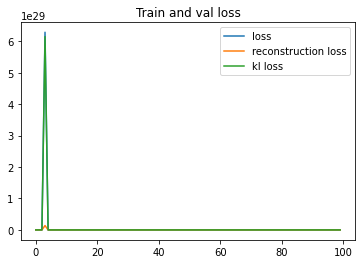

41.17853546142578


In [16]:
plt.title("Train and val loss")
plt.plot(history.history['loss'], label = 'loss')
plt.plot(history.history['reconstruction_loss'], label= 'reconstruction loss')
plt.plot(history.history['kl_loss'],label= 'kl loss')
plt.legend()
plt.show() 

print(np.min(history.history['loss']))

In [17]:
# get the embedding
get_z = keras.models.Model(inputs=[encoder_inputs], outputs=vae.get_layer("encoder").output, name="VAE")
z_output = get_z.predict({"x": scaled_data})

13/13 [==============================] - 0s 7ms/step


2023-03-06 09:16:46.218183: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


<AxesSubplot:title={'center':'PCA of embedding'}>

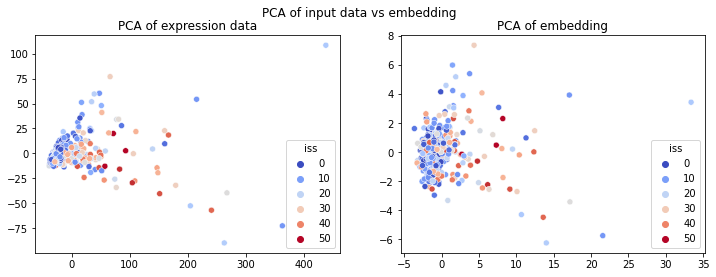

In [18]:
# extract only the releavant output
embedding = z_output[2]
pca = PCA(n_components = 4)
pca_res = pca.fit_transform(embedding)

pca_raw =  PCA(n_components = 5)
pca_res_r = pca_raw.fit_transform(scaled_data)

y = clin.iss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
fig.suptitle("PCA of input data vs embedding")
ax1.set_title("PCA of expression data")
sns.scatterplot(x = pca_res_r[:,0], y = pca_res_r[:,1], hue=y, palette = 'coolwarm', ax = ax1)
ax2.set_title("PCA of embedding")
sns.scatterplot(x = pca_res[:,0], y = pca_res[:,1], hue=y, palette = 'coolwarm', ax = ax2)

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn import model_selection
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

y = [1 if i >=25 else 0 for i in clin.iss]
X_train, X_test, y_train, y_test = train_test_split(embedding, y, random_state=122, stratify = y)

#try a random forest
rf = RandomForestClassifier(max_depth=2, class_weight = 'balanced', random_state=123)
scoring = ['accuracy', 'precision_weighted', 'recall', 'f1', 'roc_auc']
kfold = model_selection.KFold(n_splits=5, shuffle=True, random_state=125)
cv_results = model_selection.cross_validate(rf, X_train, y_train, cv=kfold, scoring=scoring)

cv_results

{'fit_time': array([0.06091404, 0.04187226, 0.04065514, 0.04053903, 0.04062891]),
 'score_time': array([0.00742912, 0.0060699 , 0.00604391, 0.00601315, 0.00602722]),
 'test_accuracy': array([0.69354839, 0.69354839, 0.82258065, 0.72580645, 0.83606557]),
 'test_precision_weighted': array([0.73687748, 0.66004963, 0.81964411, 0.77073107, 0.83088345]),
 'test_recall': array([0.64705882, 0.26315789, 0.64705882, 0.45454545, 0.625     ]),
 'test_f1': array([0.53658537, 0.34482759, 0.66666667, 0.37037037, 0.66666667]),
 'test_roc_auc': array([0.75294118, 0.62178703, 0.73333333, 0.59180036, 0.85833333])}

In [20]:
np.mean([0.75294118, 0.62178703, 0.73333333, 0.59180036, 0.85833333])

0.7116390459999999

In [28]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(class_weight = 'balanced', random_state=123)
scoring = ['accuracy', 'precision_weighted', 'recall', 'f1', 'roc_auc']
kfold = model_selection.KFold(n_splits=5, shuffle=True, random_state=125)
cv_results = model_selection.cross_validate(lr, X_train, y_train, cv=kfold, scoring=scoring)

cv_results

{'fit_time': array([0.00783324, 0.00212097, 0.00150204, 0.00176716, 0.00155401]),
 'score_time': array([0.00222373, 0.00171471, 0.00158   , 0.00165582, 0.00175619]),
 'test_accuracy': array([0.69354839, 0.69354839, 0.64516129, 0.67741935, 0.68852459]),
 'test_precision_weighted': array([0.7677216 , 0.68092567, 0.7471384 , 0.77295718, 0.72101874]),
 'test_recall': array([0.76470588, 0.42105263, 0.76470588, 0.54545455, 0.5625    ]),
 'test_f1': array([0.57777778, 0.45714286, 0.54166667, 0.375     , 0.48648649]),
 'test_roc_auc': array([0.81437908, 0.56793146, 0.71372549, 0.62566845, 0.725     ])}

In [22]:
np.mean([0.81437908, 0.56793146, 0.71372549, 0.62566845, 0.725  ])

0.689340896